# ESPM Course 2025
## Nineth Notebook
Linear diffusion equation in two dimension using an explicit finite difference scheme to impose a bonudary condition (base level) in the interior of the domain, using xarray-simlab

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xsimlab as xs
import numba
%load_ext xsimlab.ipython

The xsimlab.ipython extension is already loaded. To reload it, use:
  %reload_ext xsimlab.ipython


In [31]:
@xs.process
class Geometry:
    '''
    Process to define the geometry of the 2D grid and compute the x- and y- coordinate arrays
    as well as the grid spacings in x- and y-directions
    '''
    
    shape = xs.variable(dims="ny_nx", description="nb. of grid nodes in (y, x)", static=True)
    length = xs.variable(dims="ny_nx", intent="in", description="total grid length in (y, x)", static=True)
    
    spacing = xs.variable(dims="ny_nx", intent="out", description="grid spacing in (y, x)", static=True)
    
    x = xs.index(dims="x", description="grid x coordinate")
    y = xs.index(dims="y", description="grid y coordinate")
    
    def initialize(self):
        self.spacing = self.length / (self.shape - 1)
        self.x = np.linspace(0, self.length[1], self.shape[1])
        self.y = np.linspace(0, self.length[0], self.shape[0])


In [32]:
@xs.process
class BoundaryCondition:
    '''
    Process to define base level nodes through a boolean mask array
    where True nodes are free to evolve, where False nodes are kept at their initial elevation
    '''
    mask = xs.variable(dims=("y","x"), description="base level mask", static=True)
    

In [33]:
@xs.process
class Topography:
    '''
    Process to update the topographic elevation by adding contributions from
    erosion processes (surface_down) and tectonic uplift (surface_up)
    '''
    elevation = xs.variable(dims=("y","x"), intent="inout", description="topography elevation")
    surface_down = xs.group('surf_down')
    surface_up = xs.group('surf_up')

    def finalize_step(self):
        surface_down_tot = sum((dtopo for dtopo in self.surface_down))
        surface_up_tot = sum((dtopo for dtopo in self.surface_up))
        self.elevation = self.elevation + surface_down_tot + surface_up_tot


In [34]:
@xs.process
class Diffusion:
    '''
    Process to compute the effect of diffusion on the topography
    '''
    diffusivity = xs.variable(intent="in", description="diffusivity in (m^2/yr)")
    surface_down = xs.variable(dims=("y", "x"), intent="out", groups="surf_down", description="downward surface motion")
    shape = xs.foreign(Geometry, "shape")
    elevation = xs.foreign(Topography, "elevation")
    spacing = xs.foreign(Geometry, "spacing")
    mask = xs.foreign(BoundaryCondition, "mask")
    
    @xs.runtime(args="step_delta")
    def run_step(self, dt):
        dh = np.where(self.mask,
                      ((self.diffusivity*dt/self.spacing[1]**2)*(np.roll(self.elevation, -1, axis=1) - 2*self.elevation + np.roll(self.elevation, 1, axis=1))
                      + (self.diffusivity*dt/self.spacing[0]**2)*(np.roll(self.elevation, -1, axis=0) - 2*self.elevation + np.roll(self.elevation, 1, axis=0))),
                      0)
        self.surface_down = dh


In [35]:
@xs.process
class Uplift:
    '''
    Process to compute the increment in topography caused by tectonic uplift
    '''
    rate = xs.variable(intent="in", description="uplift rate in (m/yr)")
    surface_up = xs.variable(dims=("y", "x"), intent="out", groups="surf_up", description="uplift")
    mask = xs.foreign(BoundaryCondition, "mask")
    
    @xs.runtime(args="step_delta")
    def run_step(self, dt):
        self.surface_up = np.where(self.mask, self.rate*dt, 0)

In [7]:
model = xs.Model({'topography':Topography, 'uplift':Uplift,'diffusion':Diffusion,'geom':Geometry,'bc':BoundaryCondition})

In [12]:
nx,ny = 201,101
xl,yl, = 2000,1000
x,y = np.meshgrid(np.linspace(0,xl,nx), np.linspace(0,yl,ny))
Kd = 1e-2
U = 1e-4
tau = yl**2/Kd
tf = tau/10
nstep = 10001
nout = 11
tstep = np.linspace(0,tf,nstep)
time = np.linspace(0,tf,nout)
h0 = 100*x/xl
mask = np.ones((ny,nx), dtype=bool)
xsin = np.linspace(0,nx-1,nx).astype(int)
ysin = (np.sin(2*np.pi*xsin/nx*2)*ny/3 + ny/2).astype(int)
mask[ysin, xsin] = False

In [13]:
# %create_setup model
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={'time':time, 'tstep':tstep},
    master_clock = 'tstep',
    input_vars={
        'topography__elevation': h0,
        'uplift__rate': U,
        'diffusion__diffusivity': Kd,
        'geom__shape': [ny,nx],
        'geom__length': [yl,xl],
        'bc__mask': mask,
    },
    output_vars={'topography__elevation':'time'}
)


In [14]:
with model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run()

             0% | initialize 

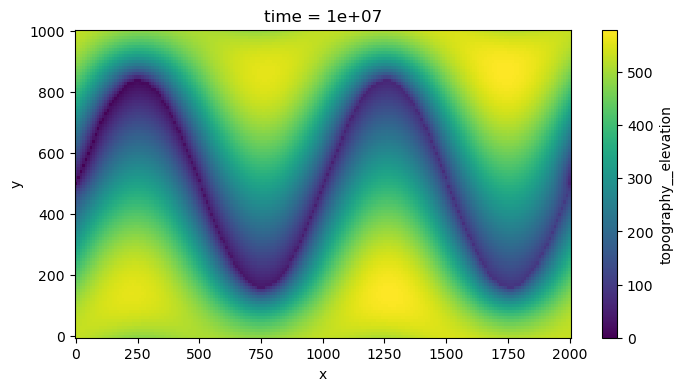

In [15]:
ds_out.topography__elevation.isel(time=-1).plot(size=4, aspect=2)

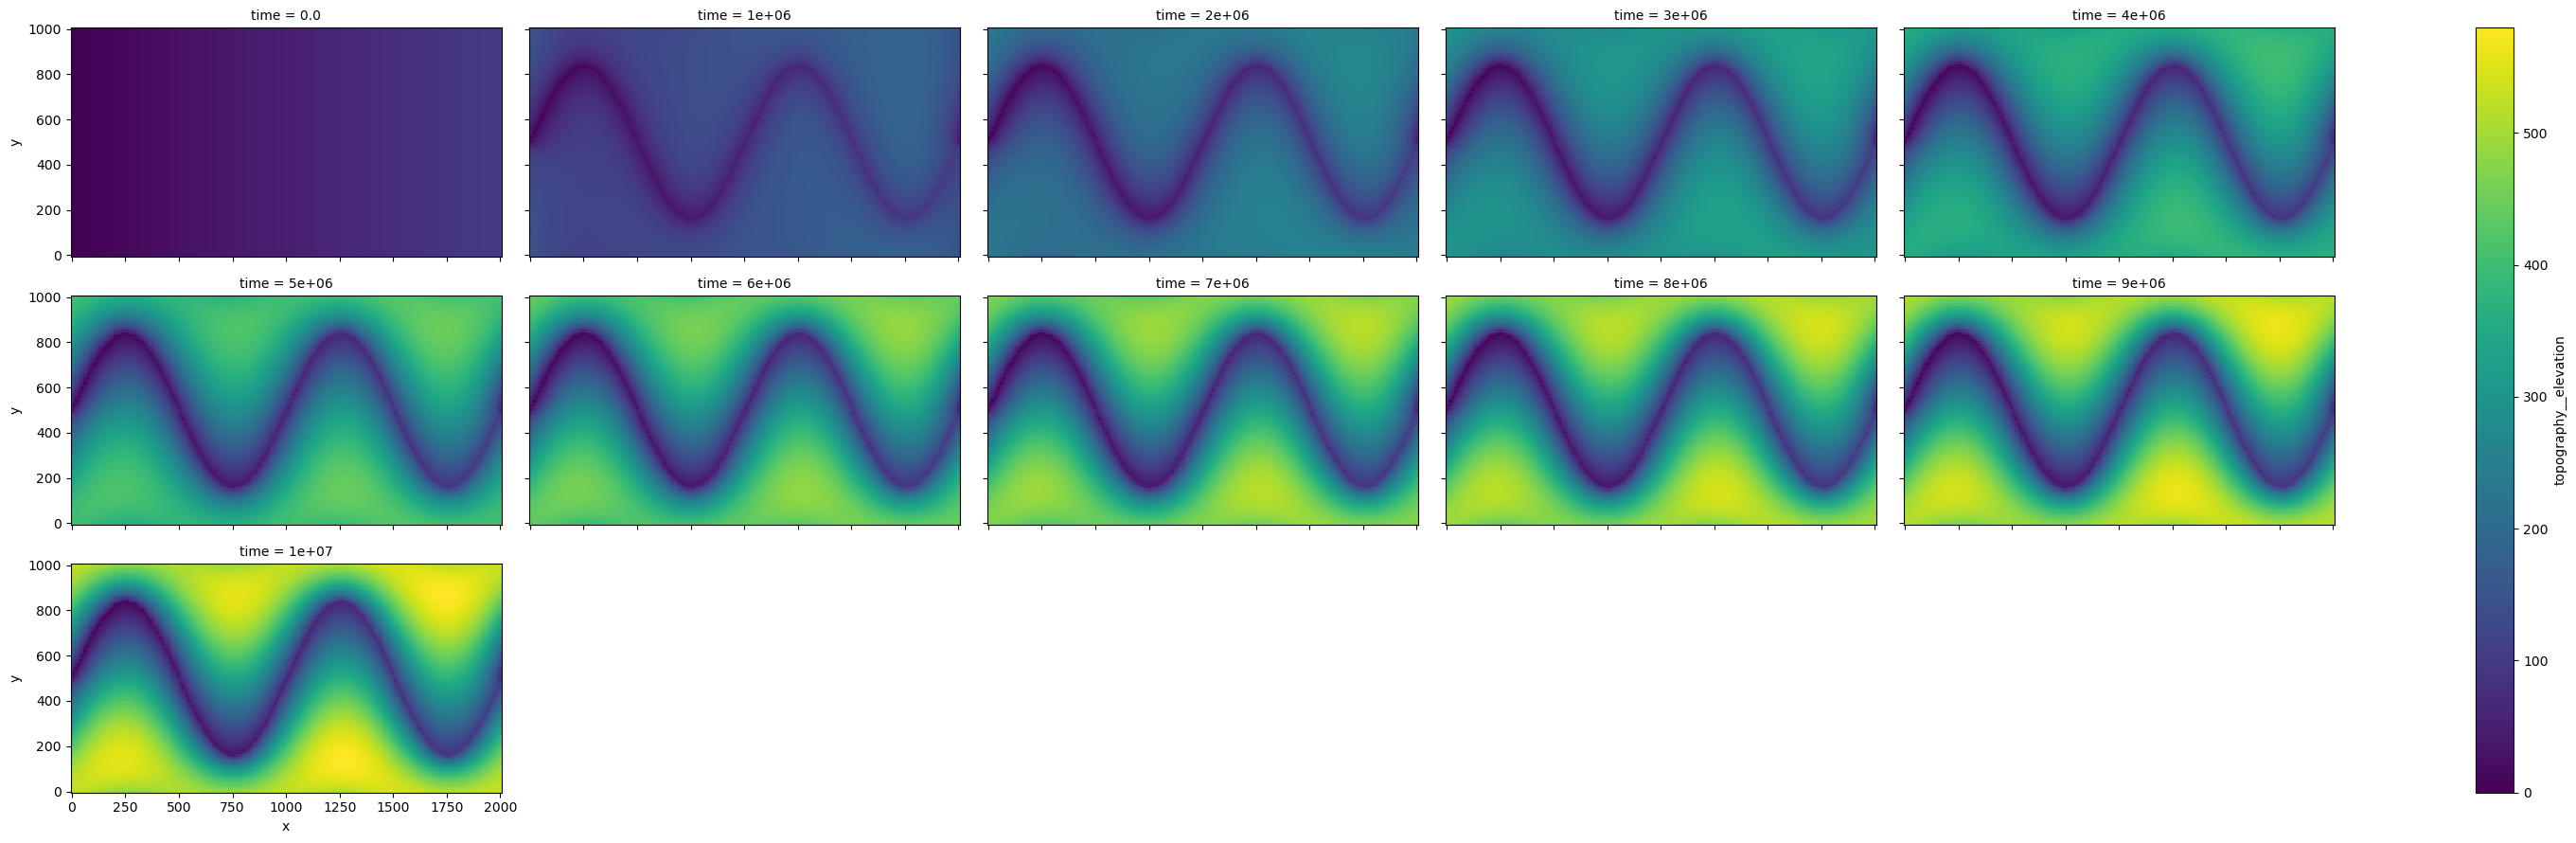

In [17]:
ds_out.topography__elevation.plot(col='time', col_wrap=5, aspect=2)

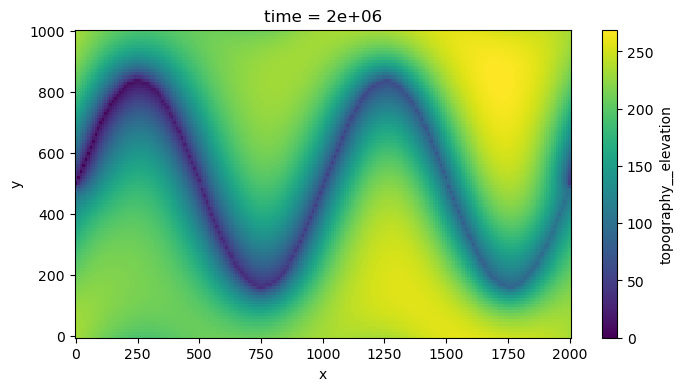

In [18]:
ds_out.topography__elevation.isel(time=2).plot(size=4, aspect=2)

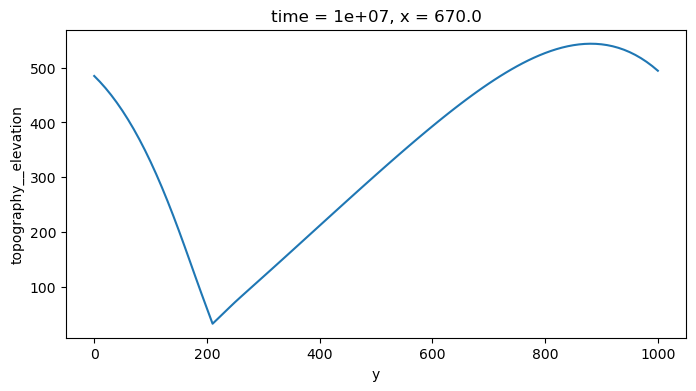

In [25]:
ds_out.topography__elevation.isel(time=-1).sel(x=xl/3, method='nearest').plot(size=4, aspect=2)

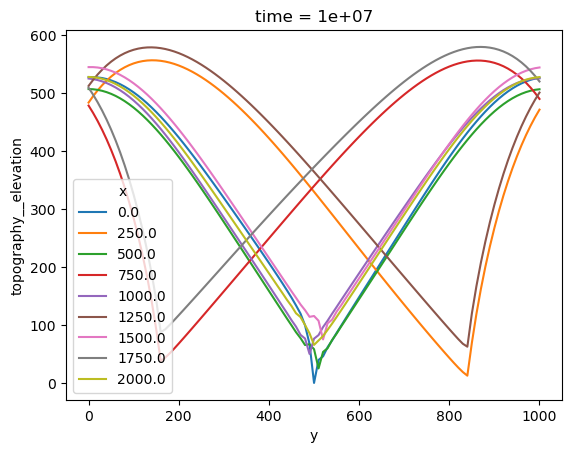

In [28]:
ds_out.topography__elevation.isel(time=-1).sel(x=ds_out.x[::25]).plot.line(x='y');

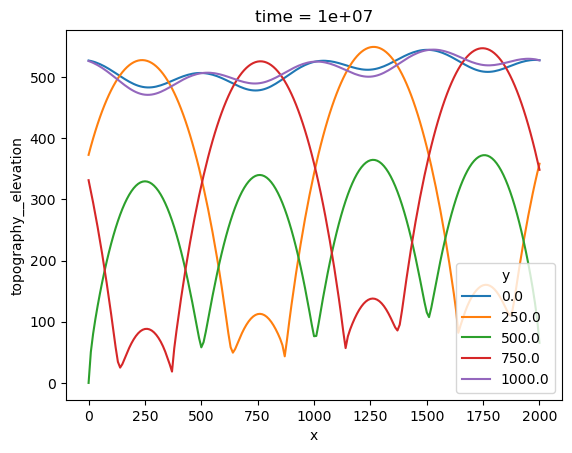

In [29]:
ds_out.topography__elevation.isel(time=-1).sel(y=ds_out.y[::25]).plot.line(x='x');